<a href="https://colab.research.google.com/github/NqobileNgidi/MIT805-Assignment/blob/main/COSMOPEDIA_MIT805_Cleaning_EDA_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%pip uninstall -y dataproc-spark-connect
%pip install -q -U pyspark==3.5.0 huggingface_hub pyarrow pandas==2.2.3 matplotlib seaborn

## IMPORTS


In [2]:
import shutil
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from huggingface_hub import snapshot_download
from pyspark.sql import SparkSession, functions as F
from pyspark.sql.functions import avg
from pyspark.sql.functions import length
from collections import Counter
import re

## DATA LOCATION


In [3]:

DATA_ROOT = Path(r"/content/cosmopedia_web_v1")
DATA_ROOT.mkdir(parents=True, exist_ok=True)
print("Data location:", DATA_ROOT)



Data location: /content/cosmopedia_web_v1


## DISK CHECK


In [4]:
total, used, free = shutil.disk_usage(str(DATA_ROOT))
print(f"Total: {total/(1024**3):.2f} GiB")
print(f"Used:  {used/(1024**3):.2f} GiB")
print(f"Free:  {free/(1024**3):.2f} GiB")

if free < 45 * (1024**3):
    raise RuntimeError(
        f"Only {free/(1024**3):.2f} GiB is free on {DATA_ROOT}. "
        "Choose a drive with substantially more free space."
    )

Total: 107.72 GiB
Used:  57.61 GiB
Free:  50.08 GiB


## DOWNLOAD ONLY web_samples_v1


In [5]:
snapshot_path = snapshot_download(
    repo_id="HuggingFaceTB/cosmopedia",
    repo_type="dataset",
    allow_patterns=["data/web_samples_v1/*.parquet"],
    local_dir=str(DATA_ROOT),
    max_workers=1,
)
print("Downloaded to:", snapshot_path)



Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 139 files:   0%|          | 0/139 [00:00<?, ?it/s]

Downloaded to: /content/cosmopedia_web_v1


## VERIFY SIZE


In [6]:
PARQUET_DIR = DATA_ROOT / "data" / "web_samples_v1"
parquet_files = sorted(PARQUET_DIR.glob("*.parquet"))

if not parquet_files:
    raise FileNotFoundError(f"No Parquet files found in {PARQUET_DIR}")

working_bytes = sum(p.stat().st_size for p in parquet_files)
print("Parquet files:", len(parquet_files))
print(f"Working dataset size: {working_bytes/(1024**3):.2f} GiB")



Parquet files: 139
Working dataset size: 36.30 GiB


## START SPARK


In [7]:
spark = (
    SparkSession.builder
    .appName("Cosmopedia_MIT805")
    .master("local[2]")
    .config("spark.sql.shuffle.partitions", "8")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.files.maxPartitionBytes", "128m")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")
print("Spark:", spark.version)



Spark: 3.5.0


## LOAD DATA


In [8]:
DATA_PATH = str(DATA_ROOT / "data" / "web_samples_v1" / "*.parquet")

df = spark.read.parquet(DATA_PATH)

print("Columns:")
print(df.columns)

print("\nSchema:")
df.printSchema()


Columns:
['text_token_length', 'prompt', 'text', 'seed_data', 'format', 'audience']

Schema:
root
 |-- text_token_length: long (nullable = true)
 |-- prompt: string (nullable = true)
 |-- text: string (nullable = true)
 |-- seed_data: string (nullable = true)
 |-- format: string (nullable = true)
 |-- audience: string (nullable = true)



## RAW RECORD COUNT


In [9]:
raw_row_count = df.count()
print(f"Raw records: {raw_row_count:,}")



Raw records: 12,426,348


## MISSING VALUES


In [10]:
df.select([
    F.sum(F.col(c).isNull().cast("long")).alias(c)
    for c in df.columns
]).show(truncate=False)



+-----------------+------+----+---------+------+--------+
|text_token_length|prompt|text|seed_data|format|audience|
+-----------------+------+----+---------+------+--------+
|0                |0     |0   |0        |0     |0       |
+-----------------+------+----+---------+------+--------+



## DUPLICATES


In [11]:
#if "text" in df.columns:
    #distinct_text_count = df.select("text").distinct().count()
   # print(f"Distinct documents: {distinct_text_count:,}")
    #print(f"Exact duplicate documents: {raw_row_count-distinct_text_count:,}")



## DESCRIPTIVE STATISTICS


In [12]:
if "text_token_length" in df.columns:
    df.select("text_token_length").summary(
        "count", "mean", "stddev", "min", "25%", "50%", "75%", "max"
    ).show()



+-------+------------------+
|summary| text_token_length|
+-------+------------------+
|  count|          12426348|
|   mean| 842.7074704490813|
| stddev|283.53602341276434|
|    min|               150|
|    25%|               691|
|    50%|               806|
|    75%|               970|
|    max|              2514|
+-------+------------------+



## CATEGORICAL EDA


In [13]:
for column in ["seed_data", "format", "audience","prompt_type"]:
    if column in df.columns:
        print(f"\nTop values: {column}")
        df.groupBy(column).count().orderBy(F.desc("count")).limit(20).show(truncate=False)




Top values: seed_data
+--------------+--------+
|seed_data     |count   |
+--------------+--------+
|web_samples_v1|12426348|
+--------------+--------+


Top values: format
+-----------------------+-------+
|format                 |count  |
+-----------------------+-------+
|textbook_academic_tone |5904416|
|blogpost               |5468378|
|textbook_narrative_tone|528057 |
|wikihow                |525497 |
+-----------------------+-------+


Top values: audience
+----------------+-------+
|audience        |count  |
+----------------+-------+
|general         |6521932|
|college_students|5904416|
+----------------+-------+



## SAFE SAMPLE FOR PLOTS


In [14]:

sample_pd = (
    df
    .sample(withReplacement=False, fraction=0.01, seed=42)
    .limit(100_000)
    .toPandas()
)
print("Plot sample:", len(sample_pd))



Plot sample: 100000


## TOKEN LENGTH


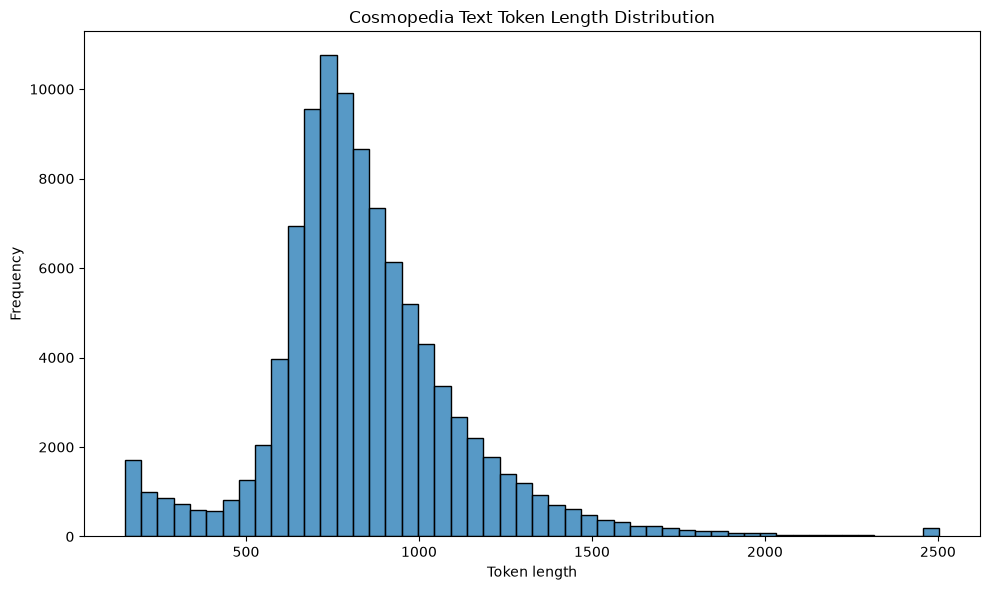

In [15]:
if "text_token_length" in sample_pd.columns:
    plt.figure(figsize=(10, 6))
    sns.histplot(sample_pd["text_token_length"].dropna(), bins=50)
    plt.title("Cosmopedia Text Token Length Distribution")
    plt.xlabel("Token length")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()



## FORMAT


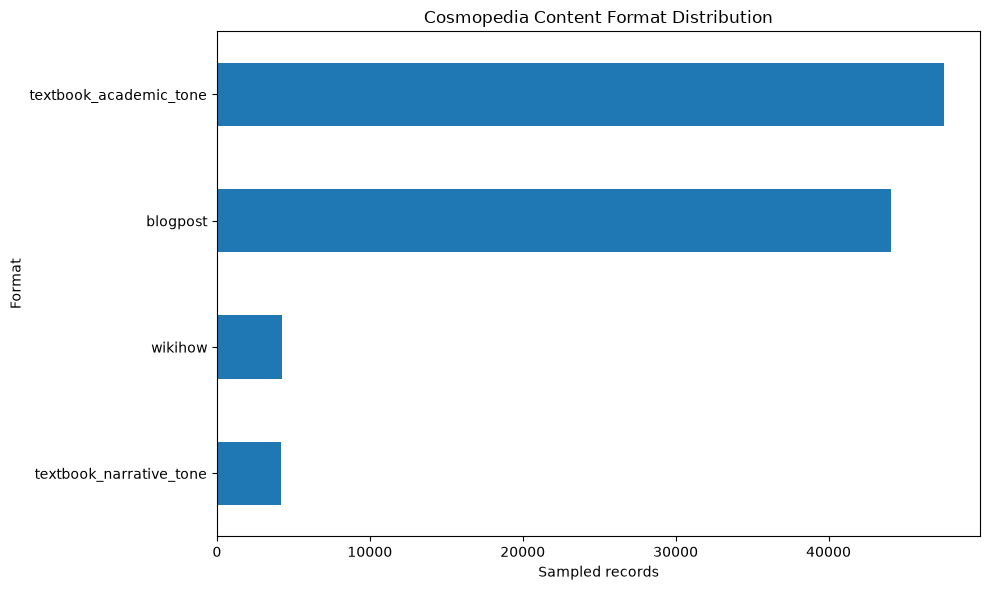

In [16]:
if "format" in sample_pd.columns:
    counts = sample_pd["format"].value_counts().head(15).sort_values()
    plt.figure(figsize=(10, 6))
    counts.plot(kind="barh")
    plt.title("Cosmopedia Content Format Distribution")
    plt.xlabel("Sampled records")
    plt.ylabel("Format")
    plt.tight_layout()
    plt.show()



In [17]:
df.groupBy("format") \
  .agg(avg("text_token_length").alias("avg_length")) \
  .orderBy("avg_length", ascending=False) \
  .show()

+--------------------+-----------------+
|              format|       avg_length|
+--------------------+-----------------+
|textbook_narrativ...|969.7690116786634|
|textbook_academic...|922.6236726883743|
|             wikihow|869.1317704953597|
|            blogpost|741.6098268993109|
+--------------------+-----------------+



## AUDIENCE


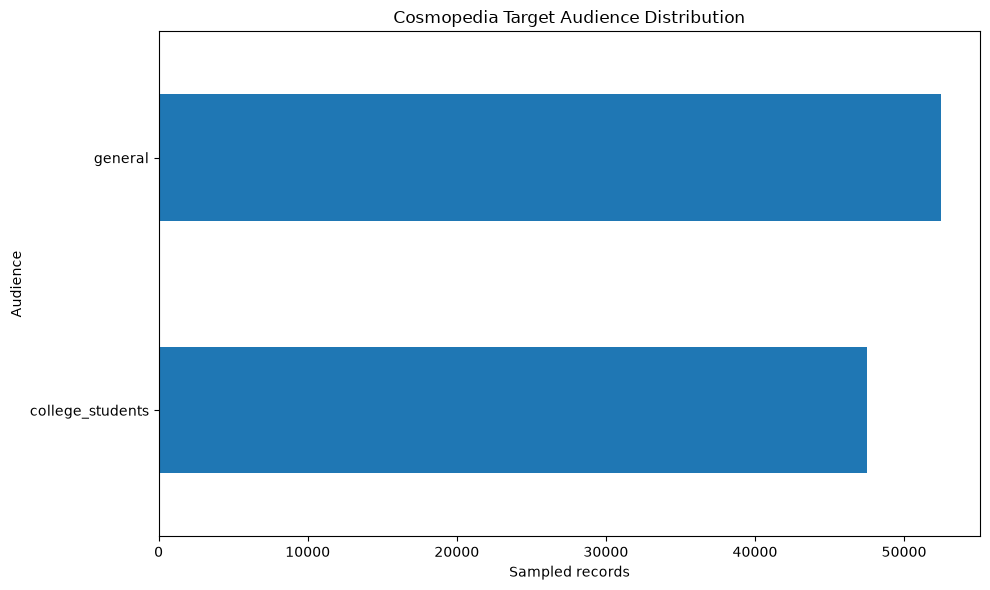

In [18]:
if "audience" in sample_pd.columns:
    counts = sample_pd["audience"].value_counts().head(15).sort_values()
    plt.figure(figsize=(10, 6))
    counts.plot(kind="barh")
    plt.title("Cosmopedia Target Audience Distribution")
    plt.xlabel("Sampled records")
    plt.ylabel("Audience")
    plt.tight_layout()
    plt.show()



In [19]:
df.groupBy("audience") \
  .agg(avg("text_token_length").alias("avg_length")) \
  .show()

+----------------+-----------------+
|        audience|       avg_length|
+----------------+-----------------+
|college_students|922.6236726883743|
|         general|770.3579729135477|
+----------------+-----------------+



## CROSS TAB ANALYSIS

In [20]:
df.groupBy(
    "format",
    "audience"
).count().show()

+--------------------+----------------+-------+
|              format|        audience|  count|
+--------------------+----------------+-------+
|            blogpost|         general|5468378|
|             wikihow|         general| 525497|
|textbook_academic...|college_students|5904416|
|textbook_narrativ...|         general| 528057|
+--------------------+----------------+-------+



## OUTLIER ANALYSIS

In [21]:
df.orderBy(
    "text_token_length",
    ascending=False
).select(
    "text_token_length",
    "format",
    "audience"
).show(20, truncate=False)

+-----------------+----------------------+----------------+
|text_token_length|format                |audience        |
+-----------------+----------------------+----------------+
|2514             |textbook_academic_tone|college_students|
|2512             |textbook_academic_tone|college_students|
|2511             |textbook_academic_tone|college_students|
|2511             |textbook_academic_tone|college_students|
|2511             |textbook_academic_tone|college_students|
|2510             |textbook_academic_tone|college_students|
|2510             |textbook_academic_tone|college_students|
|2510             |blogpost              |general         |
|2510             |textbook_academic_tone|college_students|
|2510             |textbook_academic_tone|college_students|
|2509             |textbook_academic_tone|college_students|
|2509             |textbook_academic_tone|college_students|
|2509             |textbook_academic_tone|college_students|
|2508             |textbook_academic_ton

## NLP

In [22]:
df = df.withColumn(
    "char_length",
    length("text")
)

In [23]:
df.select("char_length").summary().show()

+-------+------------------+
|summary|       char_length|
+-------+------------------+
|  count|          12426348|
|   mean|3996.7049147504963|
| stddev|  1372.96134537884|
|    min|               408|
|    25%|              3248|
|    50%|              3866|
|    75%|              4660|
|    max|             34155|
+-------+------------------+



In [24]:
sample_text = (
    df.select("text")
      .sample(False, 0.0001)
      .toPandas()
)

## EXPORT RESULTS


In [25]:
RESULTS_ROOT = DATA_ROOT / "results"
RESULTS_ROOT.mkdir(parents=True, exist_ok=True)

sample_pd.to_csv(RESULTS_ROOT / "eda_sample.csv", index=False)

print("Results saved to:", RESULTS_ROOT)


Results saved to: /content/cosmopedia_web_v1/results


In [27]:
all_text = " ".join(sample_text["text"].astype(str))

In [28]:
all_text = all_text.lower()

words = re.findall(r'\b[a-z]+\b', all_text)

word_counts = Counter(words)

In [31]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

words = [w for w in words if w not in stop_words]

Counter(words).most_common(20)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


[('like', 1593),
 ('b', 1581),
 ('unit', 1454),
 ('understanding', 1269),
 ('course', 1236),
 ('c', 1216),
 ('data', 1080),
 ('one', 1065),
 ('various', 993),
 ('development', 946),
 ('key', 927),
 ('world', 911),
 ('potential', 897),
 ('introduction', 878),
 ('conclusion', 874),
 ('time', 866),
 ('let', 863),
 ('strategies', 842),
 ('health', 811),
 ('personal', 773)]